<a href="https://colab.research.google.com/github/mulka-prog/system-devlop../blob/main/system_devlop_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Using a reliable public dataset as a placeholder due to issues with the original URL.
# This is the Titanic dataset from Kaggle.
csv_url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
output_filename = 'titanic_data.csv'

# Download the CSV file
print(f"Attempting to download data from: {csv_url}")
# Using os.system to get the exit code of wget
wget_result = os.system(f"wget {csv_url} -O {output_filename}")

df = pd.DataFrame() # Initialize df as empty DataFrame

if wget_result != 0:
    print(f"Warning: wget command failed with exit code {wget_result}. The URL might be incorrect or the server unreachable.")
    print("Please check the URL or your network connection.")
else:
    # Check if the file was actually downloaded and is not empty
    if os.path.exists(output_filename) and os.path.getsize(output_filename) > 0:
        # Load the dataset
        try:
            df = pd.read_csv(output_filename)
            print("Dataset Loaded Successfully!")
        except pd.errors.EmptyDataError:
            print(f"Error: The downloaded file '{output_filename}' is empty or has no columns to parse.")
            print("This might happen if the download was interrupted or the file is corrupted.")
        except Exception as e:
            print(f"An unexpected error occurred while reading the CSV: {e}")
    else:
        print(f"Error: Downloaded file '{output_filename}' is empty or does not exist after wget completed. This indicates an issue with the downloaded content.")

# Inform the user if df is still empty
if df.empty:
    print("Warning: DataFrame 'df' is currently empty due to download or parsing issues. Subsequent operations might not work as expected.")

Attempting to download data from: https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Dataset Loaded Successfully!


In [9]:
# Display first 5 rows
print(df.head())

# Check for missing values
print(f"Missing values: {df.isnull().sum().sum()}")

# The 'label' column is not present in the Titanic dataset, so this line is removed or commented out.
# print(df['label'].value_counts()) # This line caused a KeyError with the original empty DataFrame

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
Mi

In [12]:
# Display first 5 rows
print(df.head())

# Check for missing values
print(f"Missing values: {df.isnull().sum().sum()}")

# Summary of 'Survived' column
print(df['Survived'].value_counts())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
Mi

/tmp/ipython-input-2178512961.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Survived', palette='viridis')


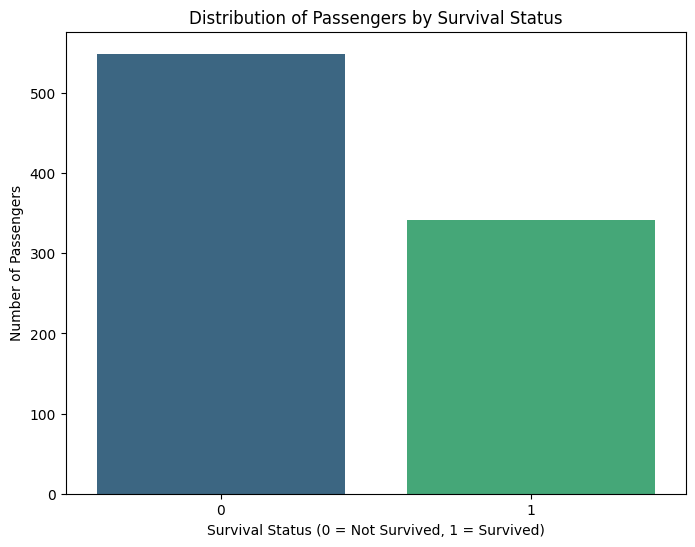

In [13]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Survived', hue='Survived', palette='viridis', legend=False)
plt.title('Distribution of Passengers by Survival Status')
plt.xlabel('Survival Status (0 = Not Survived, 1 = Survived)')
plt.ylabel('Number of Passengers')
plt.show()